# Import library

In [1]:
import pandas as pd
import numpy as np
import random
import datetime
from collections import defaultdict
import copy
import matplotlib.pyplot as plt
import mlflow
import os

print("Libraries imported successfully!")

Libraries imported successfully!


# Dataset Configuration

In [2]:
# Load the datasets
try:
    df_mk = pd.read_csv('./mk_dsi.csv')
    df_ruang = pd.read_csv('./ruang_kuliah.csv')

    # Rename columns for consistency and to remove spaces
    df_mk.columns = ['kode_mk', 'nama_mk', 'prodi', 'prioritas', 'berminat', 'dosen_id']
    df_ruang.columns = ['kode_ruang', 'lokasi', 'lantai', 'keterangan']

    # Clean data and ensure correct data types
    df_mk['dosen_id'] = df_mk['dosen_id'].fillna('Belum Ada Dosen').astype(str)

except FileNotFoundError:
    print("--- FAILED TO LOAD FILES ---")
    print("Ensure 'mk_dsi.csv' and 'ruang_kuliah.csv' are in the same directory as this notebook.")
    df_mk, df_ruang = pd.DataFrame(), pd.DataFrame() # Create empty dataframes on failure

# Check if dataframes loaded successfully before proceeding
if not df_mk.empty:
    # --- MAIN CHANGE: Treat each row as a unique item ---
    list_of_courses_to_schedule = df_mk.to_dict('records')

    # Adjust data structure for compatibility with the rest of the code.
    # The fitness function expects 'dosen_list', so create a list containing
    # the single lecturer for each course row.
    for course in list_of_courses_to_schedule:
        # The lecturer ID already exists, just wrap it in a list.
        course['dosen_list'] = [course['dosen_id']]

    list_ruang = df_ruang['kode_ruang'].unique().tolist()

    print("Data loading and pre-processing successful (each row treated as unique).")
    print(f"Total course items to schedule: {len(list_of_courses_to_schedule)}")
    print(f"Total Available Rooms: {len(list_ruang)}")
else:
    print("\nDataFrames are empty due to file loading failure. Subsequent cells will likely fail.")
    # Initialize variables to prevent errors in the next cell
    list_of_courses_to_schedule = []
    list_ruang = []
    df_ruang = pd.DataFrame() # Ensure df_ruang is defined even on failure

Data loading and pre-processing successful (each row treated as unique).
Total course items to schedule: 845
Total Available Rooms: 44


# Define Time Slot & Rooms

In [3]:
# --- Time Slot Definition ---
def generate_time_slots():
    slots = []
    days = {"Senin": 0, "Selasa": 1, "Rabu": 2, "Kamis": 3, "Jumat": 4}

    for day_name, day_index in days.items():
        start_time = datetime.datetime.strptime("07:00", "%H:%M")
        end_time = datetime.datetime.strptime("18:00", "%H:%M")

        if day_name in ["Senin", "Selasa", "Rabu", "Kamis"]:
            break_start = datetime.datetime.strptime("12:10", "%H:%M")
            break_end = datetime.datetime.strptime("12:30", "%H:%M")
        else: # Friday
            break_start = datetime.datetime.strptime("11:15", "%H:%M")
            break_end = datetime.datetime.strptime("12:30", "%H:%M")

        current_time = start_time
        while current_time < end_time:
            slot_end_time = current_time + datetime.timedelta(minutes=50)
            # Check if the slot is outside the break time
            if not (current_time >= break_start and current_time < break_end):
                 slots.append(f"{day_name}_{current_time.strftime('%H:%M')}-{slot_end_time.strftime('%H:%M')}")
            current_time = slot_end_time

    # Add special slot for non-islamic religion courses on Friday
    special_break_start = datetime.datetime.strptime("11:15", "%H:%M")
    special_slot_end = special_break_start + datetime.timedelta(minutes=50)
    slots.append(f"Jumat_{special_break_start.strftime('%H:%M')}-{special_slot_end.strftime('%H:%M')}_AGAMA_KHUSUS")

    return slots

time_slots = generate_time_slots()

# --- Room Definitions ---
# Ensure df_ruang is not empty and has the required columns
if not df_ruang.empty and 'keterangan' in df_ruang.columns and 'kode_ruang' in df_ruang.columns:
    ruang_lab = [r['kode_ruang'] for i, r in df_ruang.iterrows() if isinstance(r.get('keterangan'), str) and 'lab' in r['keterangan'].lower()]
    # Use list_ruang which was defined in the previous cell
    ruang_reguler = [r for r in list_ruang if r not in ruang_lab]
else:
    ruang_lab = []
    ruang_reguler = []
    print("WARNING: DataFrame df_ruang is empty or missing required columns ('keterangan', 'kode_ruang'). Room definitions may be inaccurate.")


# Mark courses that require a lab, now iterating through list_of_courses_to_schedule
# Ensure list_of_courses_to_schedule is not empty
if list_of_courses_to_schedule:
    for course in list_of_courses_to_schedule:
        # Check if 'nama_mk' exists and is a string before checking for 'praktikum'
        if isinstance(course.get('nama_mk'), str) and 'praktikum' in course['nama_mk'].lower():
            course['jenis'] = 'lab'
        else:
            course['jenis'] = 'reguler'
else:
    print("WARNING: list_of_courses_to_schedule is empty. Marking course types skipped.")


print(f"Total Available Time Slots: {len(time_slots)}")
print(f"Total Regular Rooms: {len(ruang_reguler)}, Total Lab Rooms: {len(ruang_lab)}")

Total Available Time Slots: 70
Total Regular Rooms: 44, Total Lab Rooms: 0


# Function to Evaluate

In [4]:
HARD_CONSTRAINT_PENALTY = 100
SOFT_CONSTRAINT_PENALTY = 1

def calculate_fitness(schedule, df_ruang_details, time_slots_list):
    """Calculates the fitness score for a single schedule (solution). Lower is better."""
    hard_violations = 0
    soft_score = 0

    room_time_usage = defaultdict(int)
    dosen_time_usage = defaultdict(list)

    # Iterating through each course allocation in the schedule
    for slot in schedule:
        # Hard Constraint #1: Room and Time Conflict
        room_time_key = (slot.get('ruang', 'N/A'), slot.get('waktu', 'N/A')) # Use .get for safety
        room_time_usage[room_time_key] += 1
        if room_time_usage[room_time_key] > 1:
            hard_violations += 1

        # Hard Constraint #2 & #3: Lecturer Conflict
        # Ensure 'dosen_list' exists and is iterable
        dosen_list = slot.get('dosen_list', [])
        current_time_slot = slot.get('waktu', 'N/A')
        if isinstance(dosen_list, list):
             for dosen in dosen_list:
                if dosen in dosen_time_usage[current_time_slot]:
                    hard_violations += 1
                dosen_time_usage[current_time_slot].append(dosen)
        else:
             # Handle case where dosen_list might not be a list as expected
             print(f"Warning: 'dosen_list' for course {slot.get('kode_mk')} is not a list: {dosen_list}")


    # Soft Constraint #1: Course Priority
    # Use .get with a default value (e.g., a high priority number if missing)
    total_priority = sum(s.get('prioritas', 10) for s in schedule) # Assume 10 if priority is missing
    soft_score += total_priority

    # Soft Constraint #2: Lecturer Movement
    dosen_schedule = defaultdict(list)
    for s in schedule:
        dosen_list = s.get('dosen_list', [])
        if isinstance(dosen_list, list):
            for dosen in dosen_list:
                 dosen_schedule[dosen].append({'waktu': s.get('waktu'), 'ruang': s.get('ruang')})

    # Ensure df_ruang_details is not empty before proceeding
    if not df_ruang_details.empty:
        for dosen, movements in dosen_schedule.items():
            if len(movements) > 1:
                # Filter out entries with missing 'waktu' before sorting
                valid_movements = [m for m in movements if m['waktu'] is not None and m['waktu'] in time_slots_list]
                if len(valid_movements) > 1:
                    try:
                        sorted_movements = sorted(valid_movements, key=lambda x: time_slots_list.index(x['waktu']))
                        for i in range(len(sorted_movements) - 1):
                             # Check if schedules are consecutive
                             if time_slots_list.index(sorted_movements[i+1]['waktu']) == time_slots_list.index(sorted_movements[i]['waktu']) + 1:
                                try:
                                    lantai_1 = df_ruang_details[df_ruang_details['kode_ruang'] == sorted_movements[i]['ruang']]['lantai'].iloc[0]
                                    lantai_2 = df_ruang_details[df_ruang_details['kode_ruang'] == sorted_movements[i+1]['ruang']]['lantai'].iloc[0]
                                    perbedaan_lantai = abs(lantai_1 - lantai_2)
                                    if perbedaan_lantai > 1:
                                        soft_score += perbedaan_lantai * SOFT_CONSTRAINT_PENALTY
                                except (IndexError, KeyError):
                                    # Handle cases where room code might not be found or floor data is missing
                                    # print(f"Warning: Could not find floor info for room {sorted_movements[i]['ruang']} or {sorted_movements[i+1]['ruang']}")
                                    continue
                    except ValueError as e:
                        # Handle cases where a time slot from the schedule might not be in the canonical time_slots_list
                        # print(f"Warning: Error sorting movements for lecturer {dosen}. Invalid time slot? Error: {e}")
                        continue # Skip this lecturer if sorting fails
    else:
        print("Warning: df_ruang_details is empty. Lecturer movement penalty calculation skipped.")


    return (hard_violations * HARD_CONSTRAINT_PENALTY) + soft_score, hard_violations

# Helper function to create a random schedule
def create_random_schedule(courses, rooms_reg, rooms_lab, times):
    schedule = []
    # Ensure rooms_reg, rooms_lab, and times are not empty
    if not rooms_reg: rooms_reg = ["DEFAULT_REG_ROOM"] # Provide fallback
    if not rooms_lab: rooms_lab = ["DEFAULT_LAB_ROOM"] # Provide fallback
    if not times: times = ["DEFAULT_TIME"] # Provide fallback

    for course in courses:
        slot = copy.deepcopy(course)
        # Use .get for safety, check if rooms exist
        course_type = course.get('jenis', 'reguler')
        if course_type == 'lab':
             slot['ruang'] = random.choice(rooms_lab) if rooms_lab else "DEFAULT_LAB_ROOM"
        else:
             slot['ruang'] = random.choice(rooms_reg) if rooms_reg else "DEFAULT_REG_ROOM"

        slot['waktu'] = random.choice(times) if times else "DEFAULT_TIME"
        schedule.append(slot)
    return schedule

# Setup MLFlow

In [9]:
# Set the experiment name for MLflow. If it doesn't exist, MLflow will create it.
mlflow.set_experiment("POA_Skripsi_1")
print("MLflow experiment set to 'POA_Skripsi_1'")

2025/12/17 06:27:17 INFO mlflow.tracking.fluent: Experiment with name 'POA_Skripsi_1' does not exist. Creating a new experiment.


MLflow experiment set to 'POA_Skripsi_1'


# Puma Optimzer Algorithm

In [10]:
def poa_optimizer_mlflow(courses, rooms_reg, rooms_lab, times, df_ruang_details, time_slots_list,
                         n_population, n_generations, mutation_rate):

    if not courses:
        print("POA Warning: No courses to schedule.")
        return [], float('inf'), float('inf'), []

    population = [create_random_schedule(courses, rooms_reg, rooms_lab, times) for _ in range(n_population)]
    pop_fitness = [(ind, calculate_fitness(ind, df_ruang_details, time_slots_list)) for ind in population if ind] # Ensure ind is not empty
    best_fitness_history = []
    best_fitness_overall = float('inf')
    best_violations_overall = float('inf')
    best_schedule_overall = None


    for gen in range(n_generations):
        # Filter out invalid fitness scores before sorting
        valid_pop_fitness = [(ind, fit_viol) for ind, fit_viol in pop_fitness if fit_viol[0] != float('inf')]

        if not valid_pop_fitness:
             print(f"POA Warning: No valid solutions found in generation {gen+1}. Re-initializing population.")
             # Option 1: Re-initialize and continue
             population = [create_random_schedule(courses, rooms_reg, rooms_lab, times) for _ in range(n_population)]
             pop_fitness = [(ind, calculate_fitness(ind, df_ruang_details, time_slots_list)) for ind in population if ind]
             valid_pop_fitness = [(ind, fit_viol) for ind, fit_viol in pop_fitness if fit_viol[0] != float('inf')]
             if not valid_pop_fitness:
                 print(f"POA Error: Failed to generate valid solutions even after re-initialization in gen {gen+1}. Stopping.")
                 break # Stop if re-initialization also fails

             # Option 2: Just skip this generation's update (less ideal)
             # best_fitness_history.append(best_fitness_overall) # Log previous best
             # continue


        valid_pop_fitness.sort(key=lambda x: x[1][0])
        best_individual_current_gen = valid_pop_fitness[0][0]
        best_fitness_current_gen, best_violations_current_gen = valid_pop_fitness[0][1]

        # Update overall best if current generation's best is better
        if best_fitness_current_gen < best_fitness_overall:
             best_fitness_overall = best_fitness_current_gen
             best_violations_overall = best_violations_current_gen
             best_schedule_overall = best_individual_current_gen


        best_fitness_history.append(best_fitness_overall) # Log the best found so far overall
        # Log metric at each generation
        mlflow.log_metric("best_fitness_per_iteration", best_fitness_overall, step=gen)
        print(f"POA Generation {gen+1}/{n_generations} | Current Best Fitness: {best_fitness_overall} | Violations: {best_violations_overall}")

        new_population = [best_schedule_overall] # Elitism with the overall best

        # Update Population (Puma Movement)
        num_courses = len(courses)
        for i in range(1, n_population): # Start from 1 because best is already added
             # Select an individual to modify (can be from valid_pop_fitness or original pop_fitness)
             # Using valid_pop_fitness is safer if available
             if i < len(valid_pop_fitness):
                 current_individual = valid_pop_fitness[i][0]
             else:
                 # Fallback if not enough valid individuals, choose randomly or from original list
                 current_individual = random.choice([ind for ind, fit_viol in pop_fitness]) if pop_fitness else None

             if not current_individual or len(current_individual) != num_courses:
                 # Create a new random individual if the selected one is invalid
                 new_individual = create_random_schedule(courses, rooms_reg, rooms_lab, times)
             else:
                 new_individual = copy.deepcopy(current_individual)

                 # 1. Move towards Alpha Puma (Exploitation)
                 # Ensure best_schedule_overall exists and has correct length
                 if best_schedule_overall and len(best_schedule_overall) == num_courses:
                     for j in range(num_courses):
                        if random.random() < 0.7: # Probability to mimic alpha puma
                             # Check index boundary for best_schedule_overall
                             if j < len(best_schedule_overall):
                                 new_individual[j] = copy.deepcopy(best_schedule_overall[j]) # Deep copy needed
                             else:
                                 # Handle potential length mismatch (shouldn't happen with proper checks)
                                 pass # Or recreate this part randomly

                 # 2. Mutation (Exploration / Random Jump)
                 if random.random() < mutation_rate:
                     if num_courses > 0: # Ensure there are courses to mutate
                        gene_to_mutate = random.randint(0, num_courses - 1)

                        # Choose new time or room randomly
                        if random.random() < 0.5:
                             new_individual[gene_to_mutate]['waktu'] = random.choice(times) if times else "DEFAULT_TIME"
                        else:
                             # Use original course info for type checking
                             original_course_info = courses[gene_to_mutate]
                             possible_rooms = rooms_lab if original_course_info.get('jenis') == 'lab' else rooms_reg
                             if not possible_rooms: possible_rooms = ["DEFAULT_ROOM"] # Fallback

                             new_individual[gene_to_mutate]['ruang'] = random.choice(possible_rooms)

             new_population.append(new_individual)

        population = new_population
        pop_fitness = [(ind, calculate_fitness(ind, df_ruang_details, time_slots_list)) for ind in population if ind] # Recalculate fitness

     # Final check for the best solution after all generations
    if best_schedule_overall is None and population:
         final_valid_pop = [(ind, fit_viol) for ind, fit_viol in pop_fitness if ind and fit_viol[0] != float('inf')]
         if final_valid_pop:
             final_best = min(final_valid_pop, key=lambda x: x[1][0])
             best_schedule_overall = final_best[0]
             best_fitness_overall = final_best[1][0]
             best_violations_overall = final_best[1][1]
         else:
             return [], float('inf'), float('inf'), best_fitness_history


    final_fitness, final_violations = calculate_fitness(best_schedule_overall, df_ruang_details, time_slots_list) if best_schedule_overall else (float('inf'), float('inf'))

    return best_schedule_overall if best_schedule_overall else [], final_fitness, final_violations, best_fitness_history




# Run the POA Algorithm

In [13]:
# --- Execute and Log POA ---
print("\n--- Running Puma Optimization Algorithm with MLflow Logging ---")
poa_params = {
    "n_population": 50,
    "n_generations": 100,
    "mutation_rate": 0.2
}

if list_of_courses_to_schedule:
    with mlflow.start_run(run_name="POA_Run") as run:
        # Log parameters
        mlflow.log_params(poa_params)

        poa_best_schedule, poa_fitness, poa_violations, poa_history = poa_optimizer_mlflow(
            list_of_courses_to_schedule, ruang_reguler, ruang_lab, time_slots, df_ruang, time_slots, **poa_params
        )

        # Log final metrics
        mlflow.log_metric("final_best_fitness", poa_fitness)
        mlflow.log_metric("final_hard_violations", poa_violations)

        # Save schedule to CSV and log as an artifact
        if poa_best_schedule:
            poa_csv_path = "jadwal_poa.csv"
            try:
                pd.DataFrame(poa_best_schedule).to_csv(poa_csv_path, index=False)
                mlflow.log_artifact(poa_csv_path, "schedules")
                os.remove(poa_csv_path)
            except Exception as e:
                print(f"Error saving or logging POA schedule: {e}")
        else:
            print("No valid POA schedule found to save.")

    print("\n--- POA Run Finished ---")
    print(f"Final Best Fitness: {poa_fitness}")
    print(f"Final Hard Constraint Violations: {poa_violations}")
else:
    print("Skipping POA execution because course data is empty.")
    poa_best_schedule, poa_fitness, poa_violations, poa_history = [], float('inf'), float('inf'), []


--- Running Puma Optimization Algorithm with MLflow Logging ---
POA Generation 1/100 | Current Best Fitness: 20833 | Violations: 196
POA Generation 2/100 | Current Best Fitness: 20394 | Violations: 192
POA Generation 3/100 | Current Best Fitness: 19412 | Violations: 182
POA Generation 4/100 | Current Best Fitness: 18707 | Violations: 175
POA Generation 5/100 | Current Best Fitness: 17707 | Violations: 165
POA Generation 6/100 | Current Best Fitness: 17707 | Violations: 165
POA Generation 7/100 | Current Best Fitness: 17413 | Violations: 162
POA Generation 8/100 | Current Best Fitness: 17206 | Violations: 160
POA Generation 9/100 | Current Best Fitness: 17115 | Violations: 159
POA Generation 10/100 | Current Best Fitness: 17106 | Violations: 159
POA Generation 11/100 | Current Best Fitness: 17006 | Violations: 158
POA Generation 12/100 | Current Best Fitness: 16906 | Violations: 157
POA Generation 13/100 | Current Best Fitness: 16706 | Violations: 155
POA Generation 14/100 | Current Be

# Puma Optimizer Algorithm - V1

In [11]:
import itertools
import pandas as pd
import mlflow
import os
import matplotlib.pyplot as plt

# --- 1. Definisi Hyperparameter Space ---
param_grid = {
    "n_population": [200],
    "n_generations": [500],
    "mutation_rate": [0.3]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total percobaan yang akan dijalankan: {len(combinations)}")

# --- 2. Inisialisasi Variabel Global (PENTING) ---
best_global_fitness = float('inf')
best_global_params = {}
best_global_schedule = []  # Untuk menyimpan struktur jadwal terbaik
best_global_history = []   # Untuk menyimpan history konvergensi terbaik

# --- 3. Proses Tuning ---
for i, params in enumerate(combinations):
    run_name = f"POA_Tuning_Run_{i+1}"

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        print(f"[{i+1}/{len(combinations)}] Running with: {params}")

        # Eksekusi POA
        schedule, fitness, violations, history = poa_optimizer_mlflow(
            list_of_courses_to_schedule,
            ruang_reguler,
            ruang_lab,
            time_slots,
            df_ruang,
            time_slots,
            **params
        )

        mlflow.log_metric("final_fitness", fitness)

        # --- LOGIKA PENYIMPANAN TERBAIK ---
        if fitness < best_global_fitness:
            print(f"   >>> New Best Found! (Fitness: {fitness:.2f})")
            best_global_fitness = fitness
            best_global_params = params

            # COPY data penting ke variabel global agar tidak hilang
            best_global_schedule = schedule[:] # Gunakan slicing [:] untuk copy value, bukan referensi
            best_global_history = history[:]

print(f"\n--- Tuning Selesai ---")
print(f"Best Fitness Global: {best_global_fitness}")
print(f"Best Params Global: {best_global_params}")

# --- 4. Penyimpanan Hasil Akhir (Post-Processing) ---

# A. Simpan Jadwal Terbaik ke CSV
if best_global_schedule:
    csv_filename = "best_schedule_optimized_global.csv"
    try:
        df_best = pd.DataFrame(best_global_schedule)
        df_best.to_csv(csv_filename, index=False)
        print(f"[SUCCESS] Jadwal terbaik disimpan ke: {csv_filename}")

        # Opsional: Log artifact ke MLflow run terakhir atau buat run baru khusus summary
    except Exception as e:
        print(f"[ERROR] Gagal menyimpan CSV: {e}")
else:
    print("[WARNING] Tidak ada jadwal yang dihasilkan.")

Total percobaan yang akan dijalankan: 1
[1/1] Running with: {'n_population': 200, 'n_generations': 500, 'mutation_rate': 0.3}
POA Generation 1/500 | Current Best Fitness: 20474 | Violations: 193
POA Generation 2/500 | Current Best Fitness: 19611 | Violations: 184
POA Generation 3/500 | Current Best Fitness: 18617 | Violations: 174
POA Generation 4/500 | Current Best Fitness: 17914 | Violations: 167
POA Generation 5/500 | Current Best Fitness: 17107 | Violations: 159
POA Generation 6/500 | Current Best Fitness: 16806 | Violations: 156
POA Generation 7/500 | Current Best Fitness: 16306 | Violations: 151
POA Generation 8/500 | Current Best Fitness: 16213 | Violations: 150
POA Generation 9/500 | Current Best Fitness: 16012 | Violations: 148
POA Generation 10/500 | Current Best Fitness: 15812 | Violations: 146
POA Generation 11/500 | Current Best Fitness: 15712 | Violations: 145
POA Generation 12/500 | Current Best Fitness: 15516 | Violations: 143
POA Generation 13/500 | Current Best Fitnes

# Puma Optimizer Algorithm - V1 - Convergent Chart


--- Creating Final Optimization Report ---


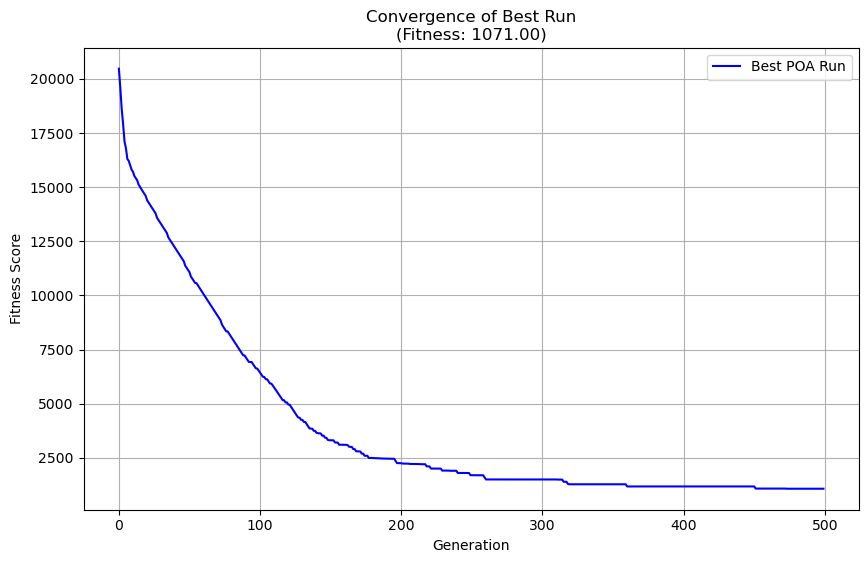

[SUCCESS] Grafik konvergensi disimpan ke: best_convergence_chart.png


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import mlflow
import os
import numpy as np

print("\n--- Creating Final Optimization Report ---")

# B. Plot Convergence Chart untuk Run Terbaik
if best_global_history:
    plt.figure(figsize=(10, 6))
    plt.plot(best_global_history, label="Best POA Run", color="blue")
    plt.title(f"Convergence of Best Run\n(Fitness: {best_global_fitness:.2f})")
    plt.xlabel("Generation")
    plt.ylabel("Fitness Score")
    plt.legend()
    plt.grid(True)

    plot_filename = "best_convergence_chart.png"
    plt.savefig(plot_filename)
    plt.show()
    print(f"[SUCCESS] Grafik konvergensi disimpan ke: {plot_filename}")
else:
    print("[WARNING] History kosong, tidak bisa membuat grafik.")